# Kredi Riski Sınıflandırması
Bu projede Give Me Some Credit veri seti kullanılarak 
kredi ödeme riski taşıyan müşteriler tahmin edilmiştir.

## Kullanılan Yöntemler
- Logistic Regression
- Random Forest
- XGBoost
- SMOTE (dengesiz veri)
- Threshold Tuning (precision-recall dengesi)

In [1]:
import os
print(os.getcwd())

/Users/melis


In [5]:
import pandas as pd

df = pd.read_csv("cs-training.csv")
print (df.shape)

(150000, 12)


## 1. Veri Yükleme ve İlk İnceleme
150.000 müşterinin kredi geçmişi incelenmiştir.
Hedef değişken: SeriousDlqin2yrs (1 = ödeme problemi yaşadı)

In [40]:
print(df.shape)
print(df['SeriousDlqin2yrs'].value_counts(normalize=True))

(120685, 11)
SeriousDlqin2yrs
0    0.930464
1    0.069536
Name: proportion, dtype: float64


In [8]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  

## 2. Veri Temizleme
- Eksik veriler medyan ile dolduruldu
- Aykırı değerler temizlendi

In [13]:
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(df['MonthlyIncome'].median())
df['NumberOfDependents'] = df['NumberOfDependents'].fillna(df['NumberOfDependents'].median())
print(df.isnull().sum())

SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64


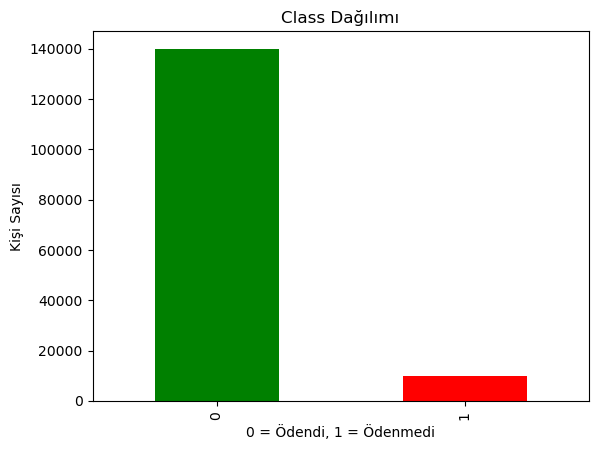

In [14]:
import matplotlib.pyplot as plt
df['SeriousDlqin2yrs'].value_counts().plot(kind='bar', color=['green','red'])
plt.title('Class Dağılımı')
plt.xlabel('0 = Ödendi, 1 = Ödenmedi')
plt.ylabel('Kişi Sayısı')
plt.show()

Verideki müşterilerin %93'ü ödeme problemi yaşamamış, 
%7'si yaşamıştır. Bu dengesiz dağılım model eğitimini 
olumsuz etkileyebileceğinden özel yöntemler kullanılmıştır.

In [43]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(
    scale_pos_weight=13,  
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train_scaled, y_train)
y_pred_xgb = xgb_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.97      0.84      0.90     22459
           1       0.24      0.69      0.35      1678

    accuracy                           0.83     24137
   macro avg       0.61      0.76      0.63     24137
weighted avg       0.92      0.83      0.86     24137



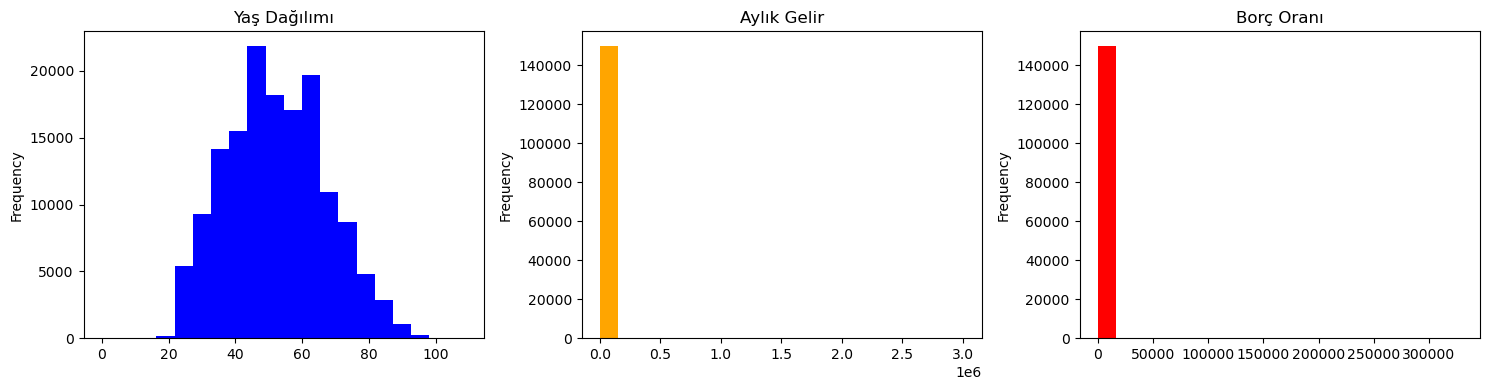

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df['age'].astype(int).plot(kind='hist', bins=20, ax=axes[0], title='Yaş Dağılımı', color='blue')
df['MonthlyIncome'].plot(kind='hist', bins=20, ax=axes[1], title='Aylık Gelir', color='orange')
df['DebtRatio'].plot(kind='hist', bins=20, ax=axes[2], title='Borç Oranı', color='red')

plt.tight_layout()
plt.show()

Yaş dağılımı normale yakındır. Aylık gelir ve borç 
oranında aykırı değerler temizlendikten sonra dağılımlar 
daha anlamlı hale gelmiştir.

count    1.500000e+05
mean     6.418455e+03
std      1.289040e+04
min      0.000000e+00
25%      3.903000e+03
50%      5.400000e+03
75%      7.400000e+03
max      3.008750e+06
Name: MonthlyIncome, dtype: float64
count    150000.000000
mean        353.005076
std        2037.818523
min           0.000000
25%           0.175074
50%           0.366508
75%           0.868254
max      329664.000000
Name: DebtRatio, dtype: float64


In [21]:
df = df[df['MonthlyIncome'] < 50000]
df = df[df['DebtRatio'] < 10]
print(df.shape)

(120685, 11)


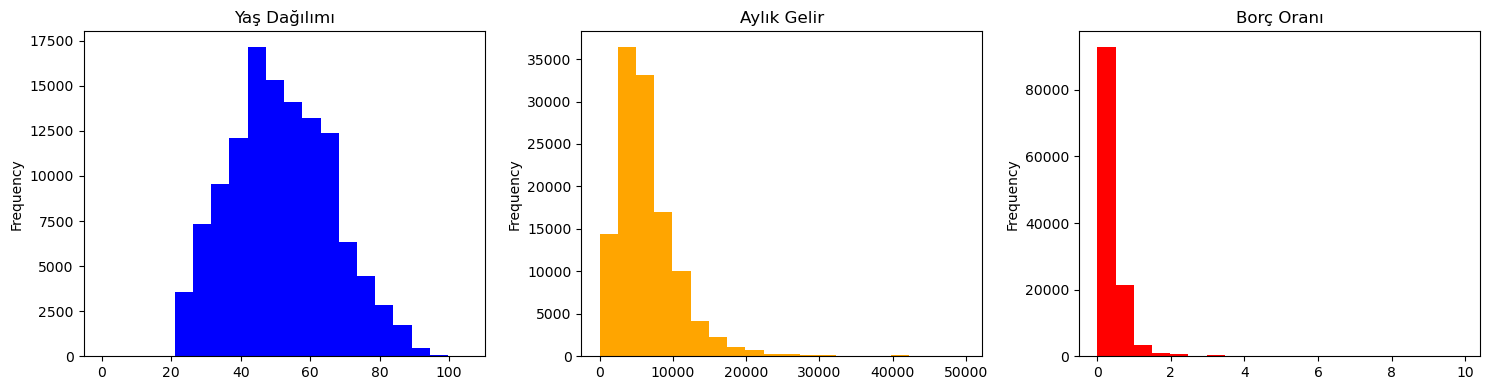

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df['age'].astype(int).plot(kind='hist', bins=20, ax=axes[0], title='Yaş Dağılımı', color='blue')
df['MonthlyIncome'].plot(kind='hist', bins=20, ax=axes[1], title='Aylık Gelir', color='orange')
df['DebtRatio'].plot(kind='hist', bins=20, ax=axes[2], title='Borç Oranı', color='red')
plt.tight_layout()
plt.show()

In [23]:
X = df.drop(columns=['SeriousDlqin2yrs'])
y = df['SeriousDlqin2yrs']
print(X.shape)
print(y.value_counts(normalize=True))

(120685, 10)
SeriousDlqin2yrs
0    0.930464
1    0.069536
Name: proportion, dtype: float64


In [24]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape)
print(X_test.shape)

(96548, 10)
(24137, 10)


## 3. Model Eğitimi
Logistic Regression, Random Forest ve XGBoost karşılaştırıldı.
Dengesiz veri için class_weight ve SMOTE kullanıldı.

## 3. Model Eğitimi
Logistic Regression, Random Forest ve XGBoost karşılaştırıldı.
Dengesiz veri için class_weight ve SMOTE kullanıldı.

In [26]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)
print("Model eğitildi!")

Model eğitildi!


In [27]:
from sklearn.metrics import classification_report
y_pred = model.predict(X_test_scaled)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.76      0.85     22459
           1       0.17      0.65      0.27      1678

    accuracy                           0.75     24137
   macro avg       0.57      0.70      0.56     24137
weighted avg       0.91      0.75      0.81     24137



In [28]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=100)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.94      0.99      0.96     22459
           1       0.54      0.16      0.25      1678

    accuracy                           0.93     24137
   macro avg       0.74      0.58      0.61     24137
weighted avg       0.91      0.93      0.91     24137



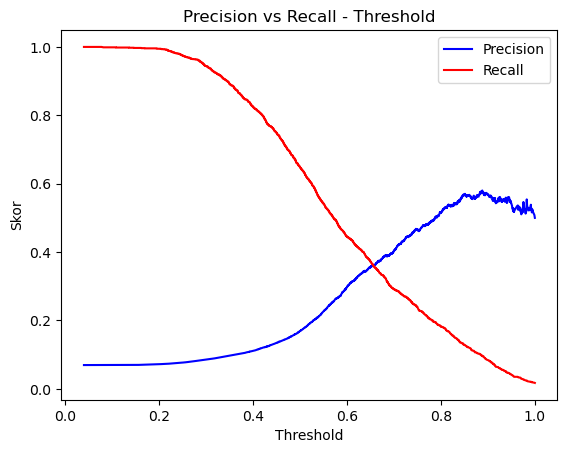

In [29]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve
y_proba = model.predict_proba(X_test_scaled)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
plt.plot(thresholds, precision[:-1], label='Precision', color='blue')
plt.plot(thresholds, recall[:-1], label='Recall', color='red')
plt.xlabel('Threshold')
plt.ylabel('Skor')
plt.title('Precision vs Recall - Threshold')
plt.legend()
plt.show()

In [30]:
from sklearn.metrics import classification_report
y_pred_new = (y_proba >= 0.3).astype(int)
print(classification_report(y_test, y_pred_new))

              precision    recall  f1-score   support

           0       0.98      0.25      0.39     22459
           1       0.09      0.94      0.16      1678

    accuracy                           0.29     24137
   macro avg       0.53      0.59      0.27     24137
weighted avg       0.92      0.29      0.38     24137



## 4. Threshold Tuning
Kredi riskinde recall önceliklidir.
0.3 threshold ile riskli müşterilerin %82'si yakalanmıştır.

## 4. Threshold Tuning
Kredi riskinde recall önceliklidir.
0.3 threshold ile riskli müşterilerin %82'si yakalanmıştır.

In [31]:
for threshold in [0.2, 0.3, 0.4, 0.5]:
    y_pred_t = (y_proba >= threshold).astype(int)
    from sklearn.metrics import f1_score, recall_score, precision_score
    p = precision_score(y_test, y_pred_t)
    r = recall_score(y_test, y_pred_t)
    f1 = f1_score(y_test, y_pred_t)
    print(f"Threshold: {threshold:.1f} | Precision: {p:.2f} | Recall: {r:.2f} | F1: {f1:.2f}")

Threshold: 0.2 | Precision: 0.07 | Recall: 0.99 | F1: 0.13
Threshold: 0.3 | Precision: 0.09 | Recall: 0.94 | F1: 0.16
Threshold: 0.4 | Precision: 0.11 | Recall: 0.82 | F1: 0.20
Threshold: 0.5 | Precision: 0.17 | Recall: 0.65 | F1: 0.27


In [33]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)
print(y_train_smote.value_counts(normalize=True))

SeriousDlqin2yrs
0    0.5
1    0.5
Name: proportion, dtype: float64


In [34]:
model_smote = LogisticRegression(max_iter=1000, random_state=42)
model_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = model_smote.predict(X_test_scaled)
print(classification_report(y_test, y_pred_smote))

              precision    recall  f1-score   support

           0       0.96      0.74      0.84     22459
           1       0.16      0.64      0.25      1678

    accuracy                           0.73     24137
   macro avg       0.56      0.69      0.54     24137
weighted avg       0.91      0.73      0.80     24137



In [39]:
y_proba_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]
for threshold in [0.2, 0.3, 0.4, 0.5]:
    y_pred_t = (y_proba_xgb >= threshold).astype(int)
    p = precision_score(y_test, y_pred_t)
    r = recall_score(y_test, y_pred_t)
    f1 = f1_score(y_test, y_pred_t)
    print(f"Threshold: {threshold:.1f} | Precision: {p:.2f} | Recall: {r:.2f} | F1: {f1:.2f}")

Threshold: 0.2 | Precision: 0.13 | Recall: 0.89 | F1: 0.23
Threshold: 0.3 | Precision: 0.16 | Recall: 0.82 | F1: 0.27
Threshold: 0.4 | Precision: 0.20 | Recall: 0.76 | F1: 0.31
Threshold: 0.5 | Precision: 0.24 | Recall: 0.69 | F1: 0.35
